In [ ]:
# %pip install onnx2tf
# %pip install onnxscript onnx

In [ ]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import onnx2tf

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = "drive/MyDrive/Dev Team Project 2026/"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
DATASET_PATH = os.path.join(ARTIFACTS_DIR, "lstm_dataset.npz")
META_PATH = os.path.join(ARTIFACTS_DIR, "lstm_dataset_meta.json")

print(f"Device: {DEVICE}")
print(f"Artifacts dir: {ARTIFACTS_DIR}")

Device: cuda
Artifacts dir: drive/MyDrive/Dev Team Project 2026/artifacts


In [8]:
print(os.listdir(ARTIFACTS_DIR))
print(DATASET_PATH)
print(META_PATH)

['lstm_dataset.npz', 'lstm_dataset_meta.json', 'lstm_model.pth', 'lstm_model.keras', 'tf_model_dir']
drive/MyDrive/Dev Team Project 2026/artifacts/lstm_dataset.npz
drive/MyDrive/Dev Team Project 2026/artifacts/lstm_dataset_meta.json


In [9]:
data = np.load(DATASET_PATH, allow_pickle=True)
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

print("Keys:", data.files)
for key in data.files:
    print(f"{key}: shape={data[key].shape}, dtype={data[key].dtype}")
print("Classes:", meta["class_names"])
print("Feature count:", meta["num_features"])

Keys: ['X_train_lstm', 'X_val_lstm', 'y_train_lstm', 'y_val_lstm']
X_train_lstm: shape=(1576, 10, 126), dtype=float32
X_val_lstm: shape=(395, 10, 126), dtype=float32
y_train_lstm: shape=(1576,), dtype=int64
y_val_lstm: shape=(395,), dtype=int64
Classes: ['3aslema', '3ayla', '5adamet', '5al-3am', '5mis', '5ou', 'a7ad', 'assam', 'baladya', 'banka', 'barnamjk', 'bent', 'bou', 'bousta', 'car', 'chabeb', 'cv', 'dar', 'demande', 'eben', 'enti', 'erb3a', 'jad', 'jadda', 'jom3a', 'karhba', 'labes', 'louage', 'lyoum', 'ma7kma', 'mar2a', 'mar7ba', 'metro', 'mostawsaf', 'n3awnek', 'nekteblk', 'non', 'o5t', 'om', 'oui', 'radio', 'sbitar', 'se7a', 'sebt', 'siye7a', 't7eb', 'ta3lim', 'ta3raf', 'ta9ra', 'taxi', 'telvza', 'tfol', 'tha9afa', 'thleth', 'thnin', 'train', 'wzara']
Feature count: 126


In [10]:
X_train_lstm = data["X_train_lstm"]
X_val_lstm = data["X_val_lstm"]
y_train_lstm = data["y_train_lstm"]
y_val_lstm = data["y_val_lstm"]

num_classes = int(meta["num_classes"] )
seq_len = int(meta["seq_len"] )
num_features = int(meta["num_features"] )

print("Train shape:", X_train_lstm.shape, y_train_lstm.shape)
print("Val shape:", X_val_lstm.shape, y_val_lstm.shape)
print("Sequence length:", seq_len)
print("Feature count:", num_features)
print("Class count:", num_classes)

Train shape: (1576, 10, 126) (1576,)
Val shape: (395, 10, 126) (395,)
Sequence length: 10
Feature count: 126
Class count: 57


In [11]:
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_lstm, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_lstm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_lstm, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64,
    shuffle=True,
    drop_last=False,
 )
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=64,
    shuffle=False,
 )

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Input tensor shape: {X_train_tensor.shape}")

Train batches: 25
Val batches: 7
Input tensor shape: torch.Size([1576, 10, 126])


In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        output, _ = self.lstm(x)
        features = output[:, -1, :]
        features = self.norm(features)
        features = self.dropout(features)
        return self.classifier(features)

model = LSTMClassifier(
    input_size=num_features,
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout=0.35,
 ).to(DEVICE)

print(model)

LSTMClassifier(
  (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (classifier): Linear(in_features=256, out_features=57, bias=True)
)


In [13]:
def accuracy_from_logits(logits, targets):
    predictions = torch.argmax(logits, dim=1)
    return (predictions == targets).float().mean().item()

def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_items = 0

    for batch_inputs, batch_targets in loader:
        batch_inputs = batch_inputs.to(DEVICE)
        batch_targets = batch_targets.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(batch_inputs)
            loss = criterion(logits, batch_targets)
            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = batch_targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (torch.argmax(logits, dim=1) == batch_targets).sum().item()
        total_items += batch_size

    return total_loss / total_items, total_correct / total_items

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

In [14]:
num_epochs = 15
best_val_acc = 0.0
best_state = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Best val accuracy: {best_val_acc:.4f}")

Epoch 01/15 | train_loss=2.8763 train_acc=0.2760 | val_loss=1.9237 val_acc=0.5063
Epoch 02/15 | train_loss=1.6598 train_acc=0.5730 | val_loss=1.2048 val_acc=0.6835
Epoch 03/15 | train_loss=1.0720 train_acc=0.7176 | val_loss=0.8262 val_acc=0.7671
Epoch 04/15 | train_loss=0.6803 train_acc=0.8242 | val_loss=0.5663 val_acc=0.8633
Epoch 05/15 | train_loss=0.4700 train_acc=0.8871 | val_loss=0.3833 val_acc=0.8861
Epoch 06/15 | train_loss=0.3297 train_acc=0.9220 | val_loss=0.2377 val_acc=0.9519
Epoch 07/15 | train_loss=0.2414 train_acc=0.9442 | val_loss=0.2250 val_acc=0.9519
Epoch 08/15 | train_loss=0.1630 train_acc=0.9664 | val_loss=0.1801 val_acc=0.9468
Epoch 09/15 | train_loss=0.1344 train_acc=0.9714 | val_loss=0.1716 val_acc=0.9494
Epoch 10/15 | train_loss=0.0865 train_acc=0.9873 | val_loss=0.1007 val_acc=0.9747
Epoch 11/15 | train_loss=0.0770 train_acc=0.9822 | val_loss=0.0859 val_acc=0.9772
Epoch 12/15 | train_loss=0.0654 train_acc=0.9886 | val_loss=0.0843 val_acc=0.9797
Epoch 13/15 | tr

Validation predictions sample: [32 12 48 10 12  9 56 11 30 53 36 19 13 26 37 40 12 28 51 11]


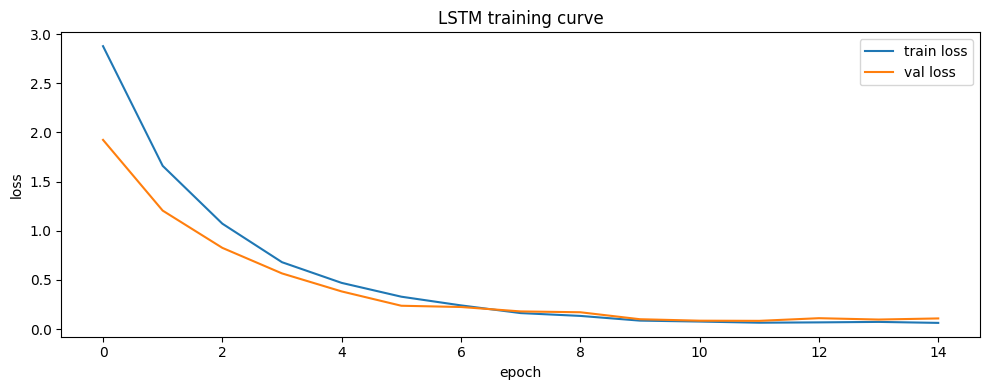

In [15]:
model.eval()
with torch.no_grad():
    val_logits = model(X_val_tensor.to(DEVICE))
    val_predictions = torch.argmax(val_logits, dim=1).cpu().numpy()

print("Validation predictions sample:", val_predictions[:20])

plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("LSTM training curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# save the model
model_path = os.path.join(ARTIFACTS_DIR, "lstm_model.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Model saved to: drive/MyDrive/Dev Team Project 2026/artifacts/lstm_model.pth


In [17]:
# model_path = os.path.join(ARTIFACTS_DIR, "lstm_model.pth")
# model.load_state_dict(torch.load(model_path, map_location=DEVICE))
# model.to(DEVICE)
# model.eval()

# print(f"Model loaded on {DEVICE}")
# print(f"seq_len={seq_len}, num_features={num_features}, num_classes={num_classes}")

In [ ]:
model.eval()
model.cpu() 

sample_input = torch.randn(1, seq_len, num_features)

torch.onnx.export(
    model,
    sample_input,
    os.path.join(ARTIFACTS_DIR, "model.onnx"),
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},  
        "output": {0: "batch_size"}
    },
    opset_version=12,  
    dynamo=False
)
print("ONNX export done")

ONNX export done


In [22]:
onnx2tf.convert(
    input_onnx_file_path=os.path.join(ARTIFACTS_DIR, "model.onnx"),
    output_folder_path=os.path.join(ARTIFACTS_DIR, "tf_model_dir"),
    non_verbose=True,
)
print("TF SavedModel export done")

flatbuffer_direct lowering:   0%|          | 0/26 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

flatbuffer_direct export:   0%|          | 0/3 [00:00<?, ?it/s]

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.043s serialize=0.029s (sanitize=0.000s build=0.004s pack=0.024s output=0.000s) write=0.012s size=2.58MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.025s serialize=0.016s (sanitize=0.000s build=0.002s pack=0.014s output=0.000s) write=0.008s size=1.30MB
TF SavedModel export done


In [23]:
TF_MODEL_DIR = os.path.join(ARTIFACTS_DIR, "tf_model_dir")
for root, dirs, files in os.walk(TF_MODEL_DIR):
    level = root.replace(TF_MODEL_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        filepath = os.path.join(root, file)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"{indent}  {file} ({size_kb:.1f} KB)")

tf_model_dir/
  schema_generated.py (660.4 KB)
  schema.fbs (43.4 KB)
  model_tensor_correspondence_report.json (23.5 KB)
  model_float32.tflite (2637.1 KB)
  model_float16.tflite (1327.8 KB)
